Aditya Mitra

10/17/2025

ENGR118_F25_L3

## Problem 1

**Create arrays/matrices, perform operations (multiplication, dot product, subtraction), transpose, index elements, and interpret results**

### A

In [1]:
import numpy as np

In [26]:
a = np.array([[2, 5],
              [3,4]])

b = np.array([[3, 7, 9],
              [0, 1, 5]])

c = np.array([[9, 6],
              [7, 2],
              [5, 1]])

d = np.array([[4, 0],
              [3, 1]])

### B

In [44]:
scalarAB = a * b

ValueError: operands could not be broadcast together with shapes (2,2) (2,3) 

This error comes up because the arrays are different sizes. Since they have two differnt shapes they aren't compatible.

In [45]:
dotAB = a@b

In [46]:
dotAB

array([[ 6, 19, 43],
       [ 9, 25, 47]])

This works because (2x2) dot (2x3) is (2x3).

In [47]:
scalarAD = a * d

In [48]:
scalarAD

array([[8, 0],
       [9, 4]])

This works because the two arrays are the same shape.

In [49]:
dotCB = c@b

In [50]:
dotCB

array([[ 27,  69, 111],
       [ 21,  51,  73],
       [ 15,  36,  50]])

In [51]:
subAD = a - d

In [52]:
subAD

array([[-2,  5],
       [ 0,  3]])

This subtracts elementwise.

### C

In [53]:
b_T = b.T

In [54]:
multBC = b_T * c

In [55]:
multBC

array([[27,  0],
       [49,  2],
       [45,  5]])

### D

(a) The first output should be 5.

In [56]:
a[0,1]

np.int64(5)

It is finding the item in the 0th row and 1st column.

(b) This will give out 1.

In [57]:
c[2,1]

np.int64(1)

In [58]:
d[1,1]

np.int64(1)

In [59]:
c[0,1]

np.int64(6)

### E

In [60]:
e = np.array([[a[0,0]],
              [b[0,0]],
              [c[0,0]],
              [d[0,0]]])

In [61]:
e

array([[2],
       [3],
       [9],
       [4]])

### F

c.shape would return (2,3) and d.shape should return (2,2).

In [62]:
print(c.shape, d.shape)

(3, 2) (2, 2)


## Problem 2

**Optimize a univariate function graphically, analytically, via bisection, and with Python’s minimize_scalar**

## A

In [63]:
import numpy as np
import matplotlib.pyplot as plt

In [64]:
def f(x):
    return (x**4)/6 + (x/2) + 3

In [65]:
x = np.linspace(-3, 3, 100)
y = f(x)

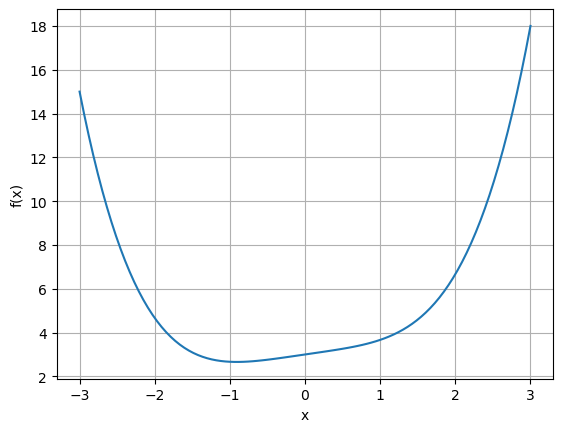

In [66]:
plt.plot(x, y)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True)
plt.show()

### B

In [70]:
import sympy as sp

In [74]:
x = sp.Symbol('x', real=True)
f_expr = (x**4)/6 + (x/2) + 3

f_prime = sp.diff(f_expr, x)

critical_points = sp.solve(sp.Eq(f_prime, 0), x)
print("Critical point(s):", critical_points)

for cp in critical_points:
    f_val = f_expr.subs(x, cp)
    print(f"f({cp}) = {f_val.evalf()}")

Critical point(s): [-6**(1/3)/2]
f(-6**(1/3)/2) = 2.65928988884397


### C

In [75]:
def df(x):
    return (2*x**3)/3 + 1/2

# Bisection function
def bisection(func, a, b, tol=1e-6):
    if func(a)*func(b) > 0:
        raise ValueError("Function has same signs at interval ends.")
    while (b - a)/2 > tol:
        mid = (a + b)/2
        if func(mid) == 0:
            return mid
        elif func(a)*func(mid) < 0:
            b = mid
        else:
            a = mid
    return (a + b)/2

root = bisection(df, -1, 0)
print("Bisection root for derivative:", root)
print("f(x) at bisection root =", f(root))

Bisection root for derivative: -0.9085607528686523
f(x) at bisection root = 2.6592898888441456


### D

In [77]:
from scipy.optimize import minimize_scalar

In [79]:
result = minimize_scalar(f, bounds=(-3, 3), method='bounded')

print("x =", result.x)

x = -0.9085601779633131


## Problem 3

**Generate a contour plot of a groundwater aquifer head function, estimate maximum location, and confirm using SciPy’s minimize**

### A

In [80]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

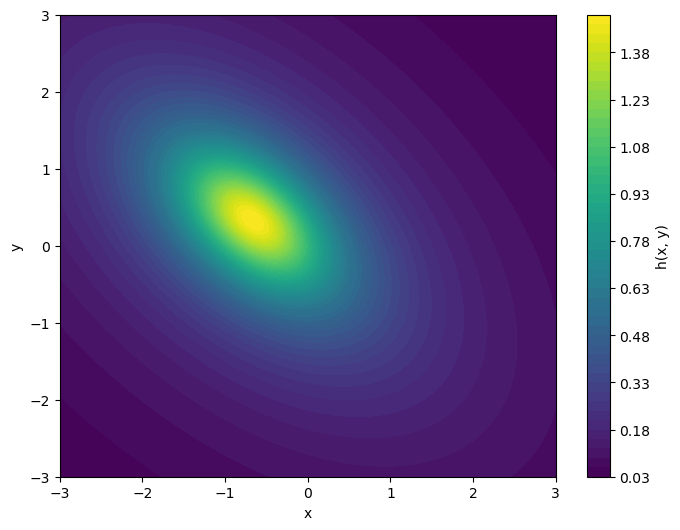

In [81]:
def h(x, y):
    return 1 / (1 + x**2 + y**2 + x*y + x)

x = np.linspace(-3, 3, 400)
y = np.linspace(-3, 3, 400)
X, Y = np.meshgrid(x, y)
Z = h(X, Y)

plt.figure(figsize=(8,6))
contour = plt.contourf(X, Y, Z, levels=50, cmap='viridis')
plt.colorbar(contour, label='h(x, y)')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

### B

In [82]:
def neg_h(vars):
    x, y = vars
    return -h(x, y)

In [83]:
# Initial guess
x0 = [0, 0]

result = minimize(neg_h, x0)
x_max, y_max = result.x
h_max = -result.fun

print(f"Maximum head value: h({x_max:.4f}, {y_max:.4f}) = {h_max:.4f}")

Maximum head value: h(-0.6667, 0.3333) = 1.5000
